## Dataset:
- Source: Kaggle.com
- Link: https://www.kaggle.com/datasets/giovamata/airlinedelaycauses?select=DelayedFlights.csv

## Problem Statement:
The U.S. Department of Transportation's (DOT) Bureau of Transportation Statistics (BTS) tracks the on-time performance of domestic flights operated by large air carriers. Summary information on the number of on-time, delayed, canceled and diverted flights appears in DOT's monthly Air Travel Consumer Report, published about 30 days after the month's end, as well as in summary tables posted on this website. BTS began collecting details on the causes of flight delays in June 2003. Summary statistics and raw data are made available to the public at the time the Air Travel Consumer Report is released.




| # | Column | Data Type | Description |
|---|--------|-----------|-------------|
| 0 | Unnamed: 0 | int64 | Index/row identifier |
| 1 | Year | int64 | Year of flight |
| 2 | Month | int64 | Month (1-12) |
| 3 | DayofMonth | int64 | Day of month (1-31) |
| 4 | DayOfWeek | int64 | Day of week |
| 5 | DepTime | float64 | Actual departure time (HHMM format) |
| 6 | CRSDepTime | int64 | Scheduled departure time (HHMM format) |
| 7 | ArrTime | float64 | Actual arrival time (HHMM format) |
| 8 | CRSArrTime | int64 | Scheduled arrival time (HHMM format) |
| 9 | UniqueCarrier | str | Airline carrier code |
| 10 | FlightNum | int64 | Flight number |
| 11 | TailNum | str | Aircraft tail number |
| 12 | ActualElapsedTime | float64 | Actual flight duration (minutes) |
| 13 | CRSElapsedTime | float64 | Scheduled flight duration (minutes) |
| 14 | AirTime | float64 | Time spent in air (minutes) |
| 15 | ArrDelay | float64 | Arrival delay (minutes; negative = early) |
| 16 | DepDelay | float64 | Departure delay (minutes; negative = early) |
| 17 | Origin | str | Origin airport code |
| 18 | Dest | str | Destination airport code |
| 19 | Distance | int64 | Flight distance (miles) |
| 20 | TaxiIn | float64 | Time from landing to gate (minutes) |
| 21 | TaxiOut | float64 | Time from gate to takeoff (minutes) |
| 22 | Cancelled | int64 | Binary: 1 if cancelled, 0 if not |
| 23 | CancellationCode | str | Reason code for cancellation |
| 24 | Diverted | int64 | Binary: 1 if diverted, 0 if not |
| 25 | CarrierDelay | float64 | Delay due to airline (minutes) |
| 26 | WeatherDelay | float64 | Delay due to weather (minutes) |
| 27 | NASDelay | float64 | Delay due to National Airspace System (minutes) |
| 28 | SecurityDelay | float64 | Delay due to security (minutes) |
| 29 | LateAircraftDelay | float64 | Delay due to previous flight being late (minutes) |

**Metadata:**
- **Total Records**: 1,936,758 flights
- **Total Columns**: 30
- **Memory Usage**: 443.3 MB
- **Missing Values**: Check NaN values in float64 columns (DepTime, ArrTime, AirTime, delay columns likely have NaN for cancelled/diverted flights)

In [129]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [130]:
df = pd.read_csv("DelayedFlights.csv")
pd.set_option("display.max_columns", None)
df.head(100)

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,NaN,NaN,NaN,NaN,NaN
1,1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,IAD,TPA,810,5.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
2,2,2008,1,3,4,628.0,620,804.0,750,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,IND,BWI,515,3.0,17.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
4,5,2008,1,3,4,1940.0,1915,2121.0,2110,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,137,2008,1,3,4,1602.0,1510,2357.0,2255,WN,3144,N272WN,295.0,285.0,269.0,62.0,52.0,LAS,ISP,2283,4.0,22.0,0,N,0,13.0,0.0,10.0,0.0,39.0
96,138,2008,1,3,4,1738.0,1715,1838.0,1820,WN,82,N499WN,60.0,65.0,42.0,18.0,23.0,LAS,LAX,236,6.0,12.0,0,N,0,0.0,0.0,0.0,12.0,6.0
97,139,2008,1,3,4,2207.0,2150,2306.0,2255,WN,135,N244WN,59.0,65.0,40.0,11.0,17.0,LAS,LAX,236,7.0,12.0,0,N,0,NaN,NaN,NaN,NaN,NaN
98,140,2008,1,3,4,1851.0,1825,2004.0,1930,WN,317,N335SW,73.0,65.0,41.0,34.0,26.0,LAS,LAX,236,16.0,16.0,0,N,0,18.0,0.0,8.0,0.0,8.0


In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1936758 entries, 0 to 1936757
Data columns (total 30 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   Year               int64  
 2   Month              int64  
 3   DayofMonth         int64  
 4   DayOfWeek          int64  
 5   DepTime            float64
 6   CRSDepTime         int64  
 7   ArrTime            float64
 8   CRSArrTime         int64  
 9   UniqueCarrier      str    
 10  FlightNum          int64  
 11  TailNum            str    
 12  ActualElapsedTime  float64
 13  CRSElapsedTime     float64
 14  AirTime            float64
 15  ArrDelay           float64
 16  DepDelay           float64
 17  Origin             str    
 18  Dest               str    
 19  Distance           int64  
 20  TaxiIn             float64
 21  TaxiOut            float64
 22  Cancelled          int64  
 23  CancellationCode   str    
 24  Diverted           int64  
 25  CarrierDelay       float64
 2

In [132]:
df.drop(columns=["Unnamed: 0"], inplace=True)
df

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,NaN,NaN,NaN,NaN,NaN
1,2008,1,3,4,754.0,735,1002.0,1000,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,IAD,TPA,810,5.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
2,2008,1,3,4,628.0,620,804.0,750,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,IND,BWI,515,3.0,17.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,2008,1,3,4,1829.0,1755,1959.0,1925,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
4,2008,1,3,4,1940.0,1915,2121.0,2110,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936753,2008,12,13,6,1250.0,1220,1617.0,1552,DL,1621,N938DL,147.0,152.0,120.0,25.0,30.0,MSP,ATL,906,9.0,18.0,0,N,0,3.0,0.0,0.0,0.0,22.0
1936754,2008,12,13,6,657.0,600,904.0,749,DL,1631,N3743H,127.0,109.0,78.0,75.0,57.0,RIC,ATL,481,15.0,34.0,0,N,0,0.0,57.0,18.0,0.0,0.0
1936755,2008,12,13,6,1007.0,847,1149.0,1010,DL,1631,N909DA,162.0,143.0,122.0,99.0,80.0,ATL,IAH,689,8.0,32.0,0,N,0,1.0,0.0,19.0,0.0,79.0
1936756,2008,12,13,6,1251.0,1240,1446.0,1437,DL,1639,N646DL,115.0,117.0,89.0,9.0,11.0,IAD,ATL,533,13.0,13.0,0,N,0,NaN,NaN,NaN,NaN,NaN


In [133]:
df["Year"].mean()

np.float64(2008.0)

Since the only year we have is **2008**, let's drop that column and rename the Dataset.

In [134]:
df.drop(columns = ["Year"], inplace = True)

In [135]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


In [136]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 1936756 entries, 0 to 1936757
Data columns (total 28 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Month              1936756 non-null  int64  
 1   DayofMonth         1936756 non-null  int64  
 2   DayOfWeek          1936756 non-null  int64  
 3   DepTime            1936756 non-null  float64
 4   CRSDepTime         1936756 non-null  int64  
 5   ArrTime            1929646 non-null  float64
 6   CRSArrTime         1936756 non-null  int64  
 7   UniqueCarrier      1936756 non-null  str    
 8   FlightNum          1936756 non-null  int64  
 9   TailNum            1936751 non-null  str    
 10  ActualElapsedTime  1928369 non-null  float64
 11  CRSElapsedTime     1936558 non-null  float64
 12  AirTime            1928369 non-null  float64
 13  ArrDelay           1928369 non-null  float64
 14  DepDelay           1936756 non-null  float64
 15  Origin             1936756 non-null  str    
 16

In [137]:
df.isnull().sum()

Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime                   0
CRSDepTime                0
ArrTime                7110
CRSArrTime                0
UniqueCarrier             0
FlightNum                 0
TailNum                   5
ActualElapsedTime      8387
CRSElapsedTime          198
AirTime                8387
ArrDelay               8387
DepDelay                  0
Origin                    0
Dest                      0
Distance                  0
TaxiIn                 7110
TaxiOut                 455
Cancelled                 0
CancellationCode          0
Diverted                  0
CarrierDelay         689270
WeatherDelay         689270
NASDelay             689270
SecurityDelay        689270
LateAircraftDelay    689270
dtype: int64

## Let's break down these nulls:
- ArrTime with **7110** nulls, meaning that **7110** flights didn't arrive, this should be replaced with a meaningful value.
- TailNum, **5** nulls, that must be missing data.
- CRSELapsedTime, **198**, missing data.
- ActualElapsedTime, AirTime, ArrDelay with **8387** nulls meaning that the flight didn't take off in the first place.
- TaxiOut has **455** nulls (likely cancelled flights—never took off).
- TaxiIn has **7110** nulls (cancelled/diverted flights—never landed at destination).
- CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay all have **689270** nulls, meaning there're all on-time flights.


In [138]:
delay_cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'TaxiOut', 'TaxiIn']
for col in delay_cause_cols:
    # If delay cause is NaN and flight arrived, it means no delay from that cause (0)
    df[col] = df[col].fillna(0)


In [139]:
df['TailNum'] = df['TailNum'].fillna('Unknown')

In [140]:
df.dropna(subset=['CRSElapsedTime'], inplace=True)

In [141]:
df.isnull().sum()

Month                   0
DayofMonth              0
DayOfWeek               0
DepTime                 0
CRSDepTime              0
ArrTime              6912
CRSArrTime              0
UniqueCarrier           0
FlightNum               0
TailNum                 0
ActualElapsedTime    8189
CRSElapsedTime          0
AirTime              8189
ArrDelay             8189
DepDelay                0
Origin                  0
Dest                    0
Distance                0
TaxiIn                  0
TaxiOut                 0
Cancelled               0
CancellationCode        0
Diverted                0
CarrierDelay            0
WeatherDelay            0
NASDelay                0
SecurityDelay           0
LateAircraftDelay       0
dtype: int64

In [142]:
df.fillna(0,inplace=True)
df.isnull().sum()

Month                0
DayofMonth           0
DayOfWeek            0
DepTime              0
CRSDepTime           0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
FlightNum            0
TailNum              0
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Dest                 0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
CancellationCode     0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64

In [143]:
np.isinf(df.select_dtypes(include=[np.number])).any()

Month                False
DayofMonth           False
DayOfWeek            False
DepTime              False
CRSDepTime           False
ArrTime              False
CRSArrTime           False
FlightNum            False
ActualElapsedTime    False
CRSElapsedTime       False
AirTime              False
ArrDelay             False
DepDelay             False
Distance             False
TaxiIn               False
TaxiOut              False
Cancelled            False
Diverted             False
CarrierDelay         False
WeatherDelay         False
NASDelay             False
SecurityDelay        False
LateAircraftDelay    False
dtype: bool

## Date Transformations

In [144]:
df['MonthName'] = pd.to_datetime(df['Month'], format='%m').dt.strftime('%b')

daysmap = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}

df['DayName'] = df['DayOfWeek'].map(daysmap)

In [145]:
df.head()

,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName
0,1,3,4,2003.0,1955,2211.0,2225,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu
1,1,3,4,754.0,735,1002.0,1000,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,IAD,TPA,810,5.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu
2,1,3,4,628.0,620,804.0,750,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,IND,BWI,515,3.0,17.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu
3,1,3,4,1829.0,1755,1959.0,1925,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu
4,1,3,4,1940.0,1915,2121.0,2110,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu


In [146]:
time_cols = ['DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime']

for col in time_cols:
    df[col] = df[col].astype(str).str.zfill(4)
    df[col + '_Hour'] = df[col].str[:2].astype(int)

In [147]:
df.head()


,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour
0,1,3,4,2003.0,1955,2211.0,2225,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22
1,1,3,4,754.0,0735,1002.0,1000,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,IAD,TPA,810,5.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,75,7,10,10
2,1,3,4,628.0,0620,804.0,0750,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,IND,BWI,515,3.0,17.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,62,6,80,7
3,1,3,4,1829.0,1755,1959.0,1925,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19
4,1,3,4,1940.0,1915,2121.0,2110,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21


In [148]:
df.info()

<class 'pandas.DataFrame'>
Index: 1936558 entries, 0 to 1936757
Data columns (total 34 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Month              int64  
 1   DayofMonth         int64  
 2   DayOfWeek          int64  
 3   DepTime            str    
 4   CRSDepTime         str    
 5   ArrTime            str    
 6   CRSArrTime         str    
 7   UniqueCarrier      str    
 8   FlightNum          int64  
 9   TailNum            str    
 10  ActualElapsedTime  float64
 11  CRSElapsedTime     float64
 12  AirTime            float64
 13  ArrDelay           float64
 14  DepDelay           float64
 15  Origin             str    
 16  Dest               str    
 17  Distance           int64  
 18  TaxiIn             float64
 19  TaxiOut            float64
 20  Cancelled          int64  
 21  CancellationCode   str    
 22  Diverted           int64  
 23  CarrierDelay       float64
 24  WeatherDelay       float64
 25  NASDelay           float64
 26  Se

In [149]:
df[df['DepTime_Hour'] > 23]

,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour
1,1,3,4,754.0,0735,1002.0,1000,WN,3231,N772SW,128.0,145.0,113.0,2.0,19.0,IAD,TPA,810,5.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,75,7,10,10
2,1,3,4,628.0,0620,804.0,0750,WN,448,N428WN,96.0,90.0,76.0,14.0,8.0,IND,BWI,515,3.0,17.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,62,6,80,7
6,1,3,4,706.0,0700,916.0,0915,WN,100,N690SW,130.0,135.0,106.0,1.0,6.0,IND,MCO,828,5.0,19.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,70,7,91,9
10,1,3,4,754.0,0745,940.0,0955,WN,1144,N778SW,226.0,250.0,205.0,-15.0,9.0,IND,PHX,1489,5.0,16.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,75,7,94,9
28,1,3,4,726.0,0720,958.0,1020,WN,3319,N206WN,152.0,180.0,140.0,-22.0,6.0,ISP,PBI,1052,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,72,7,95,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936735,12,13,6,719.0,0710,938.0,0949,DL,1491,N935DL,199.0,219.0,179.0,-11.0,9.0,LGA,MSY,1183,5.0,15.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Dec,Sat,71,7,93,9
1936736,12,13,6,753.0,0735,1054.0,1043,DL,1503,N951DL,181.0,188.0,143.0,11.0,18.0,LGA,TPA,1011,5.0,33.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Dec,Sat,75,7,10,10
1936741,12,13,6,955.0,0934,1215.0,1155,DL,1542,N912DE,140.0,141.0,114.0,20.0,21.0,ATL,BDL,859,6.0,20.0,0,N,0,20.0,0.0,0.0,0.0,0.0,Dec,Sat,95,9,12,11
1936751,12,13,6,921.0,0830,1112.0,1008,DL,1616,N907DE,111.0,98.0,82.0,64.0,51.0,ATL,PBI,545,8.0,21.0,0,N,0,51.0,0.0,13.0,0.0,0.0,Dec,Sat,92,8,11,10


**There are hours exceeding 24 hours which is logically wrong, let's drop them.**

In [150]:
for col in time_cols:
    hour = df[col].astype(str).str[:2].astype(int)
    invalid_mask = hour > 23
    
    df = df[~invalid_mask]

In [151]:
df[df['DepTime_Hour'] > 23]

,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour


In [152]:
df.drop(columns=time_cols, inplace=True)
df.head()

,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour
0,1,3,4,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22
3,1,3,4,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19
4,1,3,4,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21
5,1,3,4,WN,509,N763SW,240.0,250.0,230.0,57.0,67.0,IND,LAS,1591,3.0,7.0,0,N,0,10.0,0.0,0.0,0.0,47.0,Jan,Thu,19,18,20,19
7,1,3,4,WN,1333,N334SW,121.0,135.0,107.0,80.0,94.0,IND,MCO,828,6.0,8.0,0,N,0,8.0,0.0,0.0,0.0,72.0,Jan,Thu,16,15,18,17


In [153]:
df['DateKey'] = (
    '2008' +
    df['Month'].astype(str).str.zfill(2) +
    df['DayofMonth'].astype(str).str.zfill(2)
)
df.head()

,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour,DateKey
0,1,3,4,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22,20080103
3,1,3,4,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19,20080103
4,1,3,4,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21,20080103
5,1,3,4,WN,509,N763SW,240.0,250.0,230.0,57.0,67.0,IND,LAS,1591,3.0,7.0,0,N,0,10.0,0.0,0.0,0.0,47.0,Jan,Thu,19,18,20,19,20080103
7,1,3,4,WN,1333,N334SW,121.0,135.0,107.0,80.0,94.0,IND,MCO,828,6.0,8.0,0,N,0,8.0,0.0,0.0,0.0,72.0,Jan,Thu,16,15,18,17,20080103


## Data Modeling (Dimensions and Facts)

In [154]:
dim_date = df[['DateKey','Month', 'MonthName', 'DayofMonth', 'DayOfWeek', 'DayName']].drop_duplicates().reset_index(drop=True)
dim_date.head()

,DateKey,Month,MonthName,DayofMonth,DayOfWeek,DayName
0,20080103,1,Jan,3,4,Thu
1,20080104,1,Jan,4,5,Fri
2,20080105,1,Jan,5,6,Sat
3,20080106,1,Jan,6,7,Sun
4,20080107,1,Jan,7,1,Mon


In [155]:
dim_carrier = df[['UniqueCarrier']].drop_duplicates().reset_index(drop=True)
dim_carrier['CarrierKey'] = dim_carrier.index
df = df.merge(dim_carrier, on='UniqueCarrier', how='left')
dim_carrier.head()

,UniqueCarrier,CarrierKey
0,WN,0
1,XE,1
2,YV,2
3,OH,3
4,OO,4


In [156]:
dim_origin = df[['Origin']].drop_duplicates().reset_index(drop=True)
dim_origin['OriginKey'] = dim_origin.index

df = df.merge(dim_origin, on='Origin', how='left')
dim_origin.head()

,Origin,OriginKey
0,IAD,0
1,IND,1
2,ISP,2
3,JAN,3
4,JAX,4


In [157]:
dim_dest = df[['Dest']].drop_duplicates().reset_index(drop=True)
dim_dest['DestKey'] = dim_dest.index

df = df.merge(dim_dest, on='Dest', how='left')
dim_dest.head()

,Dest,DestKey
0,TPA,0
1,BWI,1
2,JAX,2
3,LAS,3
4,MCO,4


In [158]:
dim_time = pd.DataFrame({
    'Hour': range(24)
})

dim_time['TimeKey'] = dim_time['Hour']

def get_period(h):
    if h < 12:
        return 'Morning'
    elif h < 18:
        return 'Afternoon'
    else:
        return 'Evening'

dim_time['Period'] = dim_time['Hour'].apply(get_period)
dim_time

,Hour,TimeKey,Period
0,0,0,Morning
1,1,1,Morning
2,2,2,Morning
3,3,3,Morning
4,4,4,Morning
5,5,5,Morning
6,6,6,Morning
7,7,7,Morning
8,8,8,Morning
9,9,9,Morning


In [159]:
dim_flight = df[['FlightNum', 'TailNum']].drop_duplicates().reset_index(drop=True)
dim_flight['FlightKey'] = dim_flight.index
df = df.merge(dim_flight, on=['FlightNum', 'TailNum'], how='left')
df.head()

,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour,DateKey,CarrierKey,OriginKey,DestKey,FlightKey
0,1,3,4,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22,20080103,0,0,0,0
1,1,3,4,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19,20080103,0,1,1,1
2,1,3,4,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21,20080103,0,1,2,2
3,1,3,4,WN,509,N763SW,240.0,250.0,230.0,57.0,67.0,IND,LAS,1591,3.0,7.0,0,N,0,10.0,0.0,0.0,0.0,47.0,Jan,Thu,19,18,20,19,20080103,0,1,3,3
4,1,3,4,WN,1333,N334SW,121.0,135.0,107.0,80.0,94.0,IND,MCO,828,6.0,8.0,0,N,0,8.0,0.0,0.0,0.0,72.0,Jan,Thu,16,15,18,17,20080103,0,1,4,4


In [161]:
df.head(10)

,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour,DateKey,CarrierKey,OriginKey,DestKey,FlightKey
0,1,3,4,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22,20080103,0,0,0,0
1,1,3,4,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19,20080103,0,1,1,1
2,1,3,4,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21,20080103,0,1,2,2
3,1,3,4,WN,509,N763SW,240.0,250.0,230.0,57.0,67.0,IND,LAS,1591,3.0,7.0,0,N,0,10.0,0.0,0.0,0.0,47.0,Jan,Thu,19,18,20,19,20080103,0,1,3,3
4,1,3,4,WN,1333,N334SW,121.0,135.0,107.0,80.0,94.0,IND,MCO,828,6.0,8.0,0,N,0,8.0,0.0,0.0,0.0,72.0,Jan,Thu,16,15,18,17,20080103,0,1,4,4
5,1,3,4,WN,2272,N263WN,52.0,50.0,37.0,11.0,9.0,IND,MDW,162,6.0,9.0,0,N,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,10,10,10,10,20080103,0,1,5,5
6,1,3,4,WN,675,N286WN,228.0,240.0,213.0,15.0,27.0,IND,PHX,1489,7.0,8.0,0,N,0,3.0,0.0,0.0,0.0,12.0,Jan,Thu,14,14,16,16,20080103,0,1,6,6
7,1,3,4,WN,4,N674AA,123.0,135.0,110.0,16.0,28.0,IND,TPA,838,4.0,9.0,0,N,0,0.0,0.0,0.0,0.0,16.0,Jan,Thu,13,12,15,15,20080103,0,1,0,7
8,1,3,4,WN,54,N643SW,56.0,70.0,49.0,37.0,51.0,ISP,BWI,220,2.0,5.0,0,N,0,12.0,0.0,0.0,0.0,25.0,Jan,Thu,14,13,15,14,20080103,0,2,1,8
9,1,3,4,WN,623,N724SW,57.0,70.0,47.0,19.0,32.0,ISP,BWI,220,5.0,5.0,0,N,0,7.0,0.0,0.0,0.0,12.0,Jan,Thu,16,16,17,17,20080103,0,2,1,9


In [166]:
df['CancellationCode'].unique()

<StringArray>
['N', 'A', 'B', 'C']
Length: 4, dtype: str

Those are standard FAA cancellation codes:
- A = Carrier (Airline) - flight cancelled by the airline
- B = Weather - cancelled due to weather
- C = National Airspace System (NAS) - cancelled due to air traffic control/airport issues
- N = Security - cancelled due to security issues



In [167]:
# Map to readable names
cancellation_map = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS',
    'N': 'Security'
}

df['CancellationReason'] = df['CancellationCode'].map(cancellation_map)

# Then drop original
df = df.drop('CancellationCode', axis=1)
df.head(10)

,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour,DateKey,CarrierKey,OriginKey,DestKey,FlightKey,CancellationReason
0,1,3,4,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22,20080103,0,0,0,0,Security
1,1,3,4,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19,20080103,0,1,1,1,Security
2,1,3,4,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21,20080103,0,1,2,2,Security
3,1,3,4,WN,509,N763SW,240.0,250.0,230.0,57.0,67.0,IND,LAS,1591,3.0,7.0,0,0,10.0,0.0,0.0,0.0,47.0,Jan,Thu,19,18,20,19,20080103,0,1,3,3,Security
4,1,3,4,WN,1333,N334SW,121.0,135.0,107.0,80.0,94.0,IND,MCO,828,6.0,8.0,0,0,8.0,0.0,0.0,0.0,72.0,Jan,Thu,16,15,18,17,20080103,0,1,4,4,Security
5,1,3,4,WN,2272,N263WN,52.0,50.0,37.0,11.0,9.0,IND,MDW,162,6.0,9.0,0,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,10,10,10,10,20080103,0,1,5,5,Security
6,1,3,4,WN,675,N286WN,228.0,240.0,213.0,15.0,27.0,IND,PHX,1489,7.0,8.0,0,0,3.0,0.0,0.0,0.0,12.0,Jan,Thu,14,14,16,16,20080103,0,1,6,6,Security
7,1,3,4,WN,4,N674AA,123.0,135.0,110.0,16.0,28.0,IND,TPA,838,4.0,9.0,0,0,0.0,0.0,0.0,0.0,16.0,Jan,Thu,13,12,15,15,20080103,0,1,0,7,Security
8,1,3,4,WN,54,N643SW,56.0,70.0,49.0,37.0,51.0,ISP,BWI,220,2.0,5.0,0,0,12.0,0.0,0.0,0.0,25.0,Jan,Thu,14,13,15,14,20080103,0,2,1,8,Security
9,1,3,4,WN,623,N724SW,57.0,70.0,47.0,19.0,32.0,ISP,BWI,220,5.0,5.0,0,0,7.0,0.0,0.0,0.0,12.0,Jan,Thu,16,16,17,17,20080103,0,2,1,9,Security


In [174]:
df.loc[df['Cancelled'] == 0, 'CancellationCode'] = np.nan
df.head(10)

,Month,DayofMonth,DayOfWeek,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,MonthName,DayName,DepTime_Hour,CRSDepTime_Hour,ArrTime_Hour,CRSArrTime_Hour,DateKey,CarrierKey,OriginKey,DestKey,FlightKey,CancellationReason,CancellationCode
0,1,3,4,WN,335,N712SW,128.0,150.0,116.0,-14.0,8.0,IAD,TPA,810,4.0,8.0,0,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,20,19,22,22,20080103,0,0,0,0,Security,NaN
1,1,3,4,WN,3920,N464WN,90.0,90.0,77.0,34.0,34.0,IND,BWI,515,3.0,10.0,0,0,2.0,0.0,0.0,0.0,32.0,Jan,Thu,18,17,19,19,20080103,0,1,1,1,Security,NaN
2,1,3,4,WN,378,N726SW,101.0,115.0,87.0,11.0,25.0,IND,JAX,688,4.0,10.0,0,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,19,19,21,21,20080103,0,1,2,2,Security,NaN
3,1,3,4,WN,509,N763SW,240.0,250.0,230.0,57.0,67.0,IND,LAS,1591,3.0,7.0,0,0,10.0,0.0,0.0,0.0,47.0,Jan,Thu,19,18,20,19,20080103,0,1,3,3,Security,NaN
4,1,3,4,WN,1333,N334SW,121.0,135.0,107.0,80.0,94.0,IND,MCO,828,6.0,8.0,0,0,8.0,0.0,0.0,0.0,72.0,Jan,Thu,16,15,18,17,20080103,0,1,4,4,Security,NaN
5,1,3,4,WN,2272,N263WN,52.0,50.0,37.0,11.0,9.0,IND,MDW,162,6.0,9.0,0,0,0.0,0.0,0.0,0.0,0.0,Jan,Thu,10,10,10,10,20080103,0,1,5,5,Security,NaN
6,1,3,4,WN,675,N286WN,228.0,240.0,213.0,15.0,27.0,IND,PHX,1489,7.0,8.0,0,0,3.0,0.0,0.0,0.0,12.0,Jan,Thu,14,14,16,16,20080103,0,1,6,6,Security,NaN
7,1,3,4,WN,4,N674AA,123.0,135.0,110.0,16.0,28.0,IND,TPA,838,4.0,9.0,0,0,0.0,0.0,0.0,0.0,16.0,Jan,Thu,13,12,15,15,20080103,0,1,0,7,Security,NaN
8,1,3,4,WN,54,N643SW,56.0,70.0,49.0,37.0,51.0,ISP,BWI,220,2.0,5.0,0,0,12.0,0.0,0.0,0.0,25.0,Jan,Thu,14,13,15,14,20080103,0,2,1,8,Security,NaN
9,1,3,4,WN,623,N724SW,57.0,70.0,47.0,19.0,32.0,ISP,BWI,220,5.0,5.0,0,0,7.0,0.0,0.0,0.0,12.0,Jan,Thu,16,16,17,17,20080103,0,2,1,9,Security,NaN


In [172]:
df.isnull().sum()

Month                       0
DayofMonth                  0
DayOfWeek                   0
UniqueCarrier               0
FlightNum                   0
TailNum                     0
ActualElapsedTime           0
CRSElapsedTime              0
AirTime                     0
ArrDelay                    0
DepDelay                    0
Origin                      0
Dest                        0
Distance                    0
TaxiIn                      0
TaxiOut                     0
Cancelled                   0
Diverted                    0
CarrierDelay                0
WeatherDelay                0
NASDelay                    0
SecurityDelay               0
LateAircraftDelay           0
MonthName                   0
DayName                     0
DepTime_Hour                0
CRSDepTime_Hour             0
ArrTime_Hour                0
CRSArrTime_Hour             0
DateKey                     0
CarrierKey                  0
OriginKey                   0
DestKey                     0
FlightKey 

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1631912 entries, 0 to 1631911
Data columns (total 36 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Month               1631912 non-null  int64  
 1   DayofMonth          1631912 non-null  int64  
 2   DayOfWeek           1631912 non-null  int64  
 3   UniqueCarrier       1631912 non-null  str    
 4   FlightNum           1631912 non-null  int64  
 5   TailNum             1631912 non-null  str    
 6   ActualElapsedTime   1631912 non-null  float64
 7   CRSElapsedTime      1631912 non-null  float64
 8   AirTime             1631912 non-null  float64
 9   ArrDelay            1631912 non-null  float64
 10  DepDelay            1631912 non-null  float64
 11  Origin              1631912 non-null  str    
 12  Dest                1631912 non-null  str    
 13  Distance            1631912 non-null  int64  
 14  TaxiIn              1631912 non-null  float64
 15  TaxiOut             163191

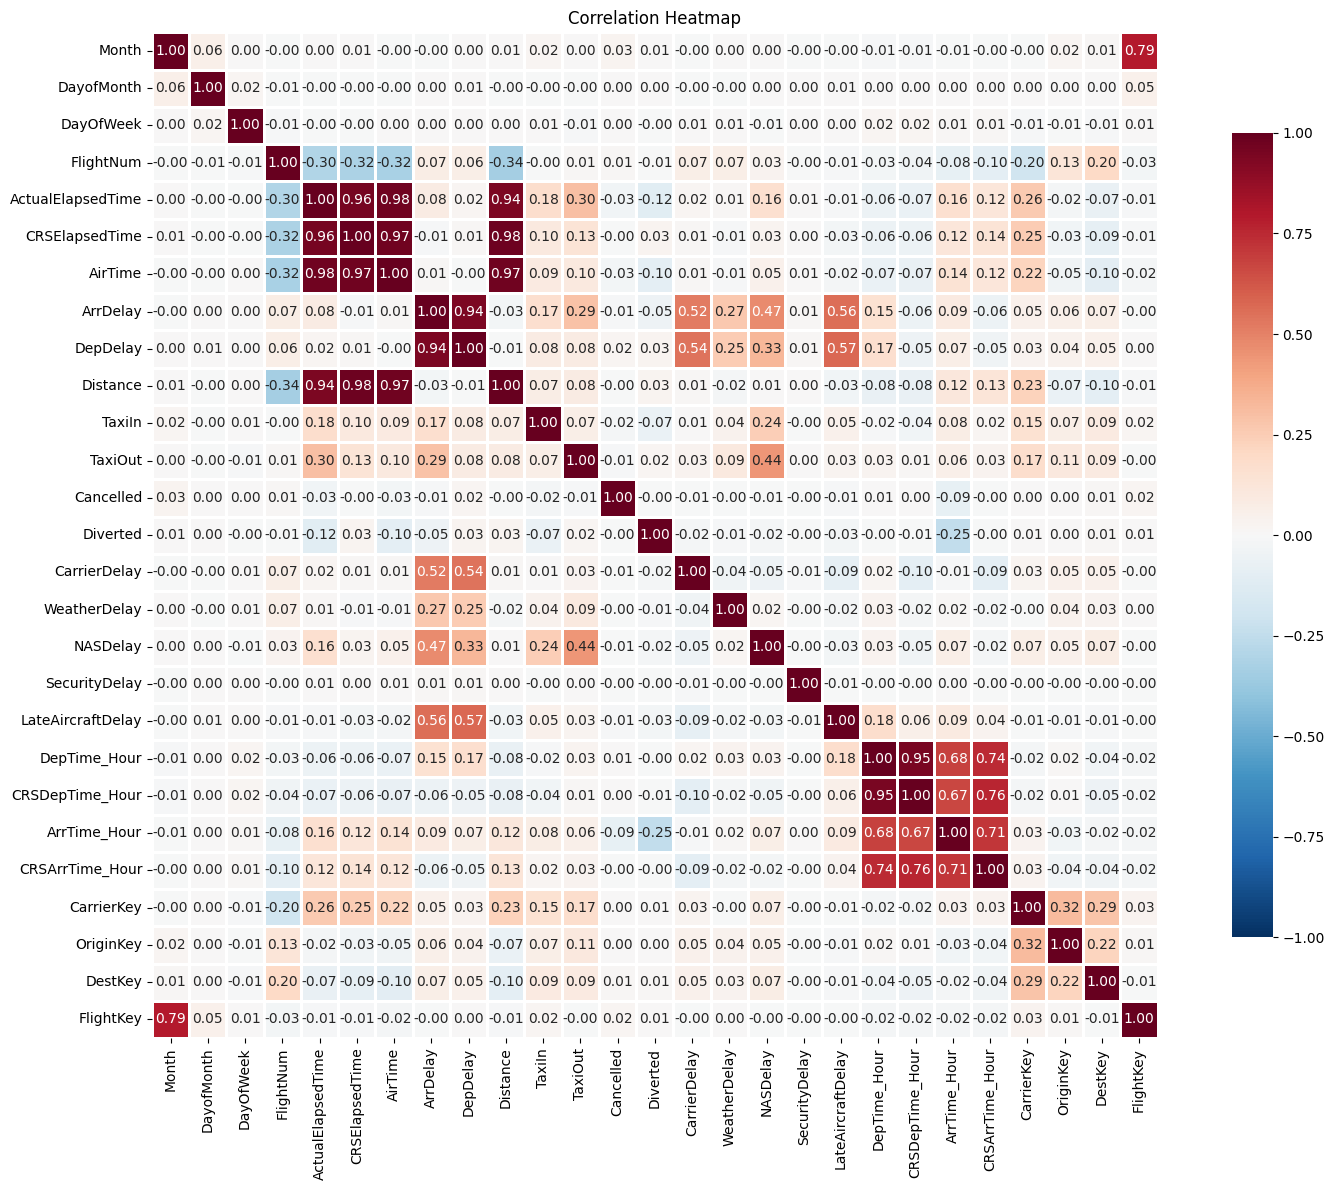

In [160]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            annot=True,
            cmap="RdBu_r",
            center=0,
            fmt=".2f",
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()